## Contains teacher - Roberta, student - distillbert

In [1]:
REPO_URL = "https://github.com/anuragupperwal/KD_MoE_CKA.git"
REPO_NAME = "KD_MoE_CKA"

!rm -rf /kaggle/working/$REPO_NAME
!git clone --depth 1 "$REPO_URL" "/kaggle/working/$REPO_NAME"
!ls -la "/kaggle/working/$REPO_NAME"


Cloning into '/kaggle/working/KD_MoE_CKA'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 18 (delta 1), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 42.89 KiB | 1.65 MiB/s, done.
Resolving deltas: 100% (1/1), done.
total 32
drwxr-xr-x 4 root root 4096 Oct 15 17:19 .
drwxr-xr-x 4 root root 4096 Oct 15 17:19 ..
drwxr-xr-x 8 root root 4096 Oct 15 17:19 .git
-rw-r--r-- 1 root root  180 Oct 15 17:19 .gitignore
-rw-r--r-- 1 root root 4186 Oct 15 17:19 README.md
-rw-r--r-- 1 root root   49 Oct 15 17:19 requirements.txt
drwxr-xr-x 6 root root 4096 Oct 15 17:19 src


In [ ]:
# to reload github repo
%cd /kaggle/working/KD_MoE_CKA
!git fetch origin
!git pull origin main   # or replace 'main' with 'master' or your branch name

In [2]:
%cd /kaggle/working/KD_MoE_CKA

# Speed + disk hygiene: set local HF cache
import os
os.environ["HF_HOME"] = "/kaggle/working/.hf_cache"

# Install from your requirements.txt 
!pip -q install -r requirements.txt

# (Optional but useful) Show versions
import torch, transformers, datasets, platform
print("Torch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Python:", platform.python_version())

/kaggle/working/KD_MoE_CKA
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 62.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 65.0 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.1.1 requires pyarrow>=21.0.0, but you have pyarrow 19.0.1 which is incompatible.
gradio 5.38.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.0a1 which is incompatible.
Torch: 2.6.0+cu124
Transformers: 4.44.2
Datasets: 4.1.1
Python: 3.11.13


In [ ]:
# !pip install transformers==4.44.2
# print("Transformers:", transformers.__version__)


In [3]:
# !pip install -U transformers accelerate datasets sentencepiece --quiet

In [3]:
!ls

README.md  requirements.txt  src


In [4]:
import sys, os
sys.path.append("/kaggle/working/KD_MoE_CKA/src")

# Optional: verify imports
from data.dataset_loader import get_dataset_and_tokenizer
from trainers.trainer import train_model

print("Imports OK")

Imports OK


<!-- # change theses paths from colab to kaggel 

## for next cell to run this
 sys.path.append(f"{MODELS_DIR}/teacher")

## For saving checkpoints
 save_path="/kaggle/working/models/teacher"

## checkpoint_dir = "/kaggle/working/models/teacher"

## For results
RESULTS_DIR = "/kaggle/working/results"
PLOTS_DIR  = "/kaggle/working/plots"



!kaggle datasets create -p /kaggle/working/models -r zip -m "Initial upload" --dir-mode tar \
     -d yourusername/thesis-checkpoints
!kaggle datasets version -p /kaggle/working/models -m "Updated teacher checkpoints"
!kaggle datasets version -p /kaggle/working/results -m "Updated training results"

 -->

In [ ]:
# !kaggle datasets list -s titanic

In [ ]:
# !hf auth login --token "token here"
# !hf auth whoami

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: fineGrained).
The token `productivity_agent` has been saved to /kaggle/working/.hf_cache/stored_tokens
Your token has been saved to /kaggle/working/.hf_cache/token
Login successful.
The current active token is: `productivity_agent`
user:  anuragupperwal


# Teacher Model

In [6]:
OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Example subfolders
CKPT_DIR = os.path.join(OUTPUT_DIR, "models/teacher")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
for d in [CKPT_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

Resume: None


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step 100, Loss = 0.5345
Step 200, Loss = 0.1640
Step 300, Loss = 0.2160
Step 400, Loss = 0.0765
Step 500, Loss = 0.1289
Step 600, Loss = 0.1530
Step 700, Loss = 0.2255
Step 800, Loss = 0.2801
Step 900, Loss = 0.0831
Step 1000, Loss = 0.0915
Step 1100, Loss = 0.1743
Step 1200, Loss = 0.1012
Step 1300, Loss = 0.3195
Step 1400, Loss = 0.2906
Step 1500, Loss = 0.3332
Step 1600, Loss = 0.1793
Step 1700, Loss = 0.5473
Step 1800, Loss = 0.0597
Step 1900, Loss = 0.3067
Step 2000, Loss = 0.1699
Step 2100, Loss = 0.0610
Step 2200, Loss = 0.0604
Step 2300, Loss = 0.3317
Step 2400, Loss = 0.0833
Step 2500, Loss = 0.2269
Step 2600, Loss = 0.2608
Step 2700, Loss = 0.1136
Step 2800, Loss = 0.1324
Step 2900, Loss = 0.1735
Step 3000, Loss = 0.0967
Step 3100, Loss = 0.1034
Step 3200, Loss = 0.1497
Step 3300, Loss = 0.0767
Epoch 1/1 | Train Loss: 0.1984 | Val Loss: 0.1474 | Val Acc: 0.9493 | F1(macro): 0.9491 | F1(weighted): 0.9494
Uploading model to Hugging Face Hub → anuragupperwal/teacher-finetuned-ro

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Pushed epoch 1 to HuggingFace Hub
Final Val Acc: 0.9493 | F1(macro): 0.9491 | F1(weighted): 0.9494


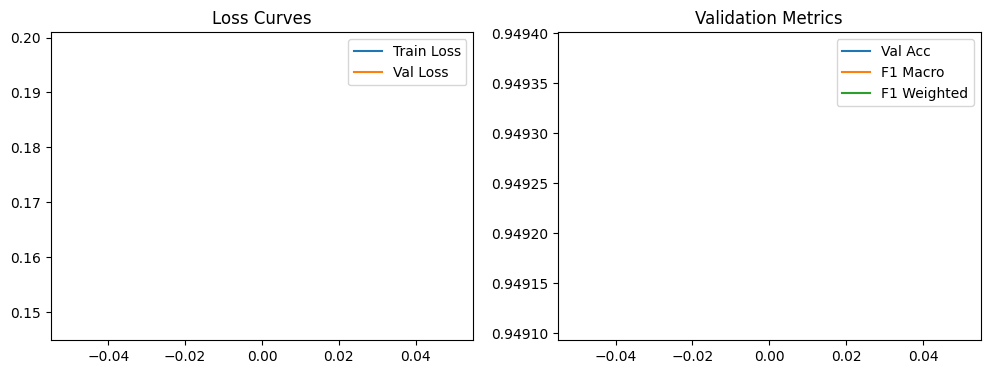


Evaluating final model on AG News test set...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Test Accuracy: 0.9484
Test Loss: 0.1564
F1 Macro: 0.9484
F1 Weighted: 0.9484


In [9]:
import json
import os, glob, sys, torch
import matplotlib.pyplot as plt

sys.path.append("/kaggle/working/KD_MoE_CKA/src")
from data.dataset_loader import get_dataset_and_tokenizer
from models.teacher_model import get_teacher_model
from trainers.utils import get_dataloaders
from trainers.trainer import train_model
from trainers.trainer import evaluate_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Find latest checkpoint
checkpoint_dir = "/kaggle/working/models"
all_ckpts = glob.glob(f"{checkpoint_dir}/teacher_*/checkpoint.pt")
resume_ckpt = max(all_ckpts, key=os.path.getmtime) if all_ckpts else None
print("Resume:", resume_ckpt)

# Data
train_ds, val_ds, test_ds, tokenizer = get_dataset_and_tokenizer(
    "roberta-large",
    train_split_ratio=0.1   #train-0.9, val-0.1
)
train_loader, val_loader = get_dataloaders(train_ds, val_ds, batch_size=32)

# Model
teacher = get_teacher_model("roberta-large").to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs with DataParallel")
    teacher = torch.nn.DataParallel(teacher)


# Train
teacher, train_losses, val_accs, val_losses, f1_macro_list, f1_weighted_list = train_model(
    model=teacher,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=1,               
    lr=2e-5,
    device=device,
    save_path="/kaggle/working/models/teacher",
    save_every=10000,
    resume_checkpoint=None,
    use_amp=True,              
    tokenizer=tokenizer,
    repo_id = "anuragupperwal/teacher-finetuned-roberta"
)

# Save metrics
import json, time
RESULTS_DIR = "/kaggle/working/teacher_results"
PLOTS_DIR  = "/kaggle/working/plots"
os.makedirs(RESULTS_DIR, exist_ok=True)
results = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "val_f1_macro": f1_macro_list,
    "val_f1_weighted": f1_weighted_list
}
with open(os.path.join(RESULTS_DIR, "results_teacher.json"), "w") as f:
    json.dump(results, f, indent=2)

if val_accs:
    print(f"Final Val Acc: {val_accs[-1]:.4f} | F1(macro): {f1_macro_list[-1]:.4f} | F1(weighted): {f1_weighted_list[-1]:.4f}")
else:
    print("No validation metrics recorded.")


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss Curves")

plt.subplot(1,2,2)
plt.plot(val_accs, label="Val Acc")
plt.plot(f1_macro_list, label="F1 Macro")
plt.plot(f1_weighted_list, label="F1 Weighted")
plt.legend(); plt.title("Validation Metrics")

plt.show()


#Evaluate on test set
print("\nEvaluating final model on AG News test set...")
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32)

test_acc, test_loss, test_f1_macro, test_f1_weighted = evaluate_model(teacher, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"F1 Macro: {test_f1_macro:.4f}")
print(f"F1 Weighted: {test_f1_weighted:.4f}")

with open("/kaggle/working/teacher_results/test_metrics_teacher.json", "w") as f:
    json.dump({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "f1_macro": test_f1_macro,
        "f1_weighted": test_f1_weighted
    }, f, indent=2)

In [ ]:
# ✅ Step 4: Evaluate on the held-out test set
from trainers.trainer import evaluate_model

print("\n🔍 Evaluating final model on AG News test set...")
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32)

test_acc, test_loss, test_f1_macro, test_f1_weighted = evaluate_model(teacher, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")
print(f"✅ F1 Macro: {test_f1_macro:.4f}")
print(f"✅ F1 Weighted: {test_f1_weighted:.4f}")

import json
with open("/kaggle/working/results/test_metrics_teacher.json", "w") as f:
    json.dump({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "f1_macro": test_f1_macro,
        "f1_weighted": test_f1_weighted
    }, f, indent=2)


🔍 Evaluating final model on AG News test set...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



✅ Test Accuracy: 0.9486
✅ Test Loss: 0.1523
✅ F1 Macro: 0.9485
✅ F1 Weighted: 0.9485


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch

# Load from HuggingFace Hub
model_name = "anuragupperwal/teacher-finetuned-roberta"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Put model on GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

import torch.nn.functional as F

texts = [
    "The crop needs irrigation due to lack of rainfall.",
    "Market prices for wheat are increasing this week.",
    "The soil quality in this region is very poor."
]

# Tokenize
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)

# Inference
with torch.no_grad():
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

print("Predictions:", preds.cpu().tolist())
print("Probabilities:", probs.cpu().numpy())

# Student Model



In [6]:

OUTPUT_DIR = "/kaggle/working/outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Example subfolders
STUD_CKPT_DIR = os.path.join(OUTPUT_DIR, "models/student")
RESULTS_DIR = os.path.join(OUTPUT_DIR, "results")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
for d in [STUD_CKPT_DIR, RESULTS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

In [7]:
# student model

import os, glob, sys, torch, json, time
import matplotlib.pyplot as plt

# Ensure src path is added
sys.path.append("/kaggle/working/KD_MoE_CKA/src")

from data.dataset_loader import get_dataset_and_tokenizer
from models.student_model import get_student_model
from trainers.utils import get_dataloaders
from trainers.trainer import train_model, evaluate_model   # include evaluate_model

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


checkpoint_dir = "/kaggle/working/models/student"
all_ckpts = glob.glob(f"{checkpoint_dir}_epoch*/checkpoint.pt")
resume_ckpt = max(all_ckpts, key=os.path.getmtime) if all_ckpts else None
print("Resume:", resume_ckpt)


train_ds, val_ds, test_ds, tokenizer = get_dataset_and_tokenizer(
    "distilbert-base-uncased",
    train_split_ratio=0.1  
)

train_loader, val_loader = get_dataloaders(train_ds, val_ds, batch_size=64)


student = get_student_model("distilbert-base-uncased").to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs with DataParallel")
    student = torch.nn.DataParallel(student)


student, train_losses, val_accs, val_losses, f1_macro_list, f1_weighted_list = train_model(
    model=student,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=1,
    lr=2e-5,
    device=device,
    save_path="/kaggle/working/models/student",
    save_every=10000,
    resume_checkpoint=None,
    use_amp=True,
    tokenizer=tokenizer,
    repo_id="anuragupperwal/student-finetuned-distilbert-base"
)


RESULTS_DIR = "/kaggle/working/student_results"
PLOTS_DIR = "/kaggle/working/student_plots"
os.makedirs(RESULTS_DIR, exist_ok=True)

results = {
    "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accs": val_accs,
    "val_f1_macro": f1_macro_list,
    "val_f1_weighted": f1_weighted_list
}
with open(os.path.join(RESULTS_DIR, "results_student.json"), "w") as f:
    json.dump(results, f, indent=2)

if val_accs:
    print(f"Final Val Acc: {val_accs[-1]:.4f} | F1(macro): {f1_macro_list[-1]:.4f} | F1(weighted): {f1_weighted_list[-1]:.4f}")
else:
    print("No validation metrics recorded.")


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend(); plt.title("Loss Curves")

plt.subplot(1, 2, 2)
plt.plot(val_accs, label="Val Acc")
plt.plot(f1_macro_list, label="F1 Macro")
plt.plot(f1_weighted_list, label="F1 Weighted")
plt.legend(); plt.title("Validation Metrics")

plt.show()


#test-student
print("\nEvaluating final model on AG News test set...")
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64)

test_acc, test_loss, test_f1_macro, test_f1_weighted = evaluate_model(student, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"F1 Macro: {test_f1_macro:.4f}")
print(f"F1 Weighted: {test_f1_weighted:.4f}")

# Save test results
os.makedirs("/kaggle/working/outputs/results", exist_ok=True)
with open("/kaggle/working/studentresults/test_metrics_student.json", "w") as f:
    json.dump({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "f1_macro": test_f1_macro,
        "f1_weighted": test_f1_weighted
    }, f, indent=2)

Resume: None


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs with DataParallel


Epoch 1:   0%|          | 0/1688 [00:00<?, ?it/s]

2025-10-15 17:21:14.155127: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760548874.533343      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760548874.657482      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


KeyboardInterrupt: 

In [7]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
import torch.nn.functional as F
import torch

# Load from HuggingFace Hub
model_name = "anuragupperwal/student-finetuned-distilbert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Put model on GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


texts = [
    "The crop needs irrigation due to lack of rainfall.",
    "Market prices for wheat are increasing this week.",
    "The soil quality in this region is very poor."
]


# Tokenize
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)

# Inference
with torch.no_grad():
    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)
    preds = torch.argmax(probs, dim=-1)

print("Predictions:", preds.cpu().tolist())
print("Probabilities:", probs.cpu().numpy())

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/807 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Predictions: [3, 2, 3]
Probabilities: [[0.32211012 0.02024507 0.21192975 0.4457151 ]
 [0.04786896 0.00213644 0.9392192  0.01077548]
 [0.21007432 0.02558914 0.13067505 0.6336615 ]]


README.md  requirements.txt  src


In [8]:
#test distilbert - non-finetuned for same dataset 
import os, glob, sys, torch, json, time
import matplotlib.pyplot as plt

# Ensure src path is added
sys.path.append("/kaggle/working/KD_MoE_CKA/src")

from data.dataset_loader import get_dataset_and_tokenizer
from trainers.utils import get_dataloaders
from models.student_model import get_student_model
from trainers.trainer import train_model, evaluate_model   # include evaluate_model

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


train_ds, val_ds, test_ds, tokenizer = get_dataset_and_tokenizer(
    "distilbert-base-uncased",
    train_split_ratio=0.1  
)

train_loader, val_loader = get_dataloaders(train_ds, val_ds, batch_size=64)


student = get_student_model("distilbert-base-uncased").to(device)

if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs with DataParallel")
    student = torch.nn.DataParallel(student)


RESULTS_DIR = "/kaggle/working/raw_distilBERT_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

#test-DistilBERT
print("\nEvaluating raw model on AG News test set...")
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=64)

test_acc, test_loss, test_f1_macro, test_f1_weighted = evaluate_model(student, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"F1 Macro: {test_f1_macro:.4f}")
print(f"F1 Weighted: {test_f1_weighted:.4f}")

# Save test results
os.makedirs("/kaggle/working/results", exist_ok=True)
with open("/kaggle/working/student_results/test_metrics_student.json", "w") as f:
    json.dump({
        "test_acc": test_acc,
        "test_loss": test_loss,
        "f1_macro": test_f1_macro,
        "f1_weighted": test_f1_weighted
    }, f, indent=2)

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Train: 108000 | Validation: 12000 | Test: 7600


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs with DataParallel

Evaluating raw model on AG News test set...


2025-10-09 17:16:58.984374: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760030219.510219      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760030219.640682      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(



Test Accuracy: 0.2453
Test Loss: 1.3941
F1 Macro: 0.0991
F1 Weighted: 0.0991


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/student_results/test_metrics_student.json'

# Comparison of the finetuned Teacher and Student model


In [11]:
#to run and evaluate both baseline finetuned models and store metrics
!python src/evaluate/compare_baseline_teacher_student.py

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Loading AG News test dataset...

Evaluating: Teacher (anuragupperwal/teacher-finetuned-roberta)
tokenizer_config.json: 1.22kB [00:00, 5.37MB/s]
vocab.json: 798kB [00:00, 9.35MB/s]
merges.txt: 456kB [00:00, 10.6MB/s]
tokenizer.json: 2.11MB [00:00, 13.8MB/s]
config.json: 100%|█████████████████████████████| 929/929 [00:00<00:00, 6.59MB/s]
model.safetensors: 100%|████████████████████| 1.42G/1.42G [00:05<00:00, 264MB/s]
100%|█████████████████████████████████████████| 238/238 [02:58<00:00,  1.33it/s]

Evaluating: Student (anuragupperwal/student-finetuned-distilbert-base)
100%|█████████████████████████████████████████| 238/238 [00:29<00:00,  7.96it/s]

MODEL PERFORMANCE COMPARISON
| Model   |   Accuracy |   Precision(Macro) |   Recall(Macro) |   F1(Macro) |   F1(Weighted) |   ROC-AUC(Macro) |
|:--------|-----------:|-------------------:|----------------:|------------:|---------------:|-----------------:|
| Teacher |   0.948421 |           0.948619 |        0.948421 |    0.94843  |       0.948

In [13]:
print(RESULTS_DIR)

/kaggle/working/results


In [ ]:
import torch, numpy as np, pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             confusion_matrix, roc_auc_score, classification_report)
from tqdm.auto import tqdm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

teacher_repo = "anuragupperwal/teacher-finetuned-roberta"
student_repo = "anuragupperwal/student-finetuned-distilbert-base"

teacher_tok = AutoTokenizer.from_pretrained(teacher_repo)
teacher = AutoModelForSequenceClassification.from_pretrained(teacher_repo).to(DEVICE).eval()

student_tok = AutoTokenizer.from_pretrained(student_repo)
student = AutoModelForSequenceClassification.from_pretrained(student_repo).to(DEVICE).eval()

id2label = {0: "Weather", 1: "Market", 2: "Soil", 3: "Other"}
num_labels = len(id2label)